In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

In [29]:
df = pd.read_csv ("/Users/kittnguyen/Documents/us-flight-project/data/raw_data/weather_meteo_by_airport.csv")
df ["time"] = pd.to_datetime (df ["time"])
df ["month"] = df ["time"].dt.month
df ["day"] = df ["time"].dt.day
df ["quarter"] = df ["time"].dt.quarter
df

,time,tavg,tmin,tmax,prcp,snow,wdir,wspd,pres,airport_id,month,day,quarter
0,2023-01-01,8.1,2.2,11.7,0.0,0.0,278.0,9.7,1013.8,ABE,1,1,1
1,2023-01-02,5.4,0.0,11.7,0.0,0.0,353.0,3.6,1019.6,ABE,1,2,1
2,2023-01-03,8.4,7.2,9.4,15.2,0.0,50.0,5.0,1013.9,ABE,1,3,1
3,2023-01-04,11.1,6.7,17.2,0.0,0.0,302.0,4.7,1009.8,ABE,1,4,1
4,2023-01-05,12.7,6.7,14.4,7.9,0.0,292.0,7.2,1013.0,ABE,1,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
132855,2023-12-27,12.2,6.7,17.6,0.0,0.0,30.0,9.6,1021.0,YUM,12,27,4
132856,2023-12-28,12.8,6.7,21.0,0.0,0.0,12.0,11.1,1020.6,YUM,12,28,4
132857,2023-12-29,13.6,7.0,20.2,0.0,0.0,22.0,13.7,1020.0,YUM,12,29,4
132858,2023-12-30,13.6,7.0,21.0,0.0,0.0,337.0,11.2,1016.5,YUM,12,30,4


In [30]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132860 entries, 0 to 132859
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   time        132860 non-null  datetime64[ns]
 1   tavg        132860 non-null  float64       
 2   tmin        132860 non-null  float64       
 3   tmax        132860 non-null  float64       
 4   prcp        132860 non-null  float64       
 5   snow        132860 non-null  float64       
 6   wdir        132860 non-null  float64       
 7   wspd        132860 non-null  float64       
 8   pres        132860 non-null  float64       
 9   airport_id  132860 non-null  object        
 10  month       132860 non-null  int32         
 11  day         132860 non-null  int32         
 12  quarter     132860 non-null  int32         
dtypes: datetime64[ns](1), float64(8), int32(3), object(1)
memory usage: 11.7+ MB


In [31]:
df.describe ()

,time,tavg,tmin,tmax,prcp,snow,wdir,wspd,pres,month,day,quarter
count,132860,132860.000000,132860.000000,132860.000000,132860.000000,132860.000000,132860.000000,132860.000000,132860.000000,132860.000000,132860.000000,132860.000000
mean,2023-07-01 23:59:59.999999744,14.042641,8.699833,19.617149,2.520604,6.810131,188.686042,12.424556,1015.650368,6.526027,15.720548,2.509589
min,2023-01-01 00:00:00,-39.100000,-76.000000,-35.000000,0.000000,0.000000,0.000000,0.000000,964.300000,1.000000,1.000000,1.000000
25%,2023-04-02 00:00:00,6.300000,1.100000,11.700000,0.000000,0.000000,79.000000,7.900000,1011.600000,4.000000,8.000000,2.000000
50%,2023-07-02 00:00:00,15.400000,9.400000,21.200000,0.000000,0.000000,197.000000,11.300000,1015.400000,7.000000,16.000000,3.000000
75%,2023-10-01 00:00:00,22.500000,17.200000,28.900000,1.000000,0.000000,297.000000,15.700000,1019.700000,10.000000,23.000000,4.000000
max,2023-12-31 00:00:00,42.200000,37.200000,50.000000,571.500000,1780.000000,360.000000,78.300000,1051.000000,12.000000,31.000000,4.000000
std,NaN,10.672859,10.680441,11.392223,7.915755,50.935283,114.629099,6.211261,6.944599,3.447864,8.796280,1.116771


In [32]:
print (f"Airport_id : {df["airport_id"].nunique ()}")
print (f"Airport_id : {df["airport_id"].unique ()}")
print ("-" * 80)

Airport_id : 364
Airport_id : ['ABE' 'ABI' 'ABQ' 'ABR' 'ABY' 'ACK' 'ACT' 'ACV' 'ACY' 'ADK' 'ADQ' 'AEX'
 'AGS' 'AKN' 'ALB' 'ALO' 'ALW' 'AMA' 'ANC' 'APN' 'ASE' 'ATL' 'ATW' 'AUS'
 'AVL' 'AVP' 'AZA' 'AZO' 'BDL' 'BET' 'BFF' 'BFL' 'BGM' 'BGR' 'BHM' 'BIH'
 'BIL' 'BIS' 'BJI' 'BLI' 'BLV' 'BMI' 'BNA' 'BOI' 'BOS' 'BPT' 'BQK' 'BQN'
 'BRD' 'BRO' 'BRW' 'BTM' 'BTR' 'BTV' 'BUF' 'BUR' 'BWI' 'BZN' 'CAE' 'CAK'
 'CDC' 'CDV' 'CEC' 'CHA' 'CHO' 'CHS' 'CID' 'CIU' 'CKB' 'CLD' 'CLE' 'CLL'
 'CLT' 'CMH' 'CMI' 'CMX' 'CNY' 'COD' 'COS' 'COU' 'CPR' 'CRP' 'CRW' 'CSG'
 'CVG' 'CWA' 'CYS' 'DAB' 'DAL' 'DAY' 'DBQ' 'DCA' 'DDC' 'DEC' 'DEN' 'DFW'
 'DHN' 'DIK' 'DLG' 'DLH' 'DRO' 'DRT' 'DSM' 'DTW' 'DVL' 'EAT' 'EAU' 'ECP'
 'EGE' 'EKO' 'ELM' 'ELP' 'ERI' 'ESC' 'EUG' 'EVV' 'EWN' 'EWR' 'EYW' 'FAI'
 'FAR' 'FAT' 'FAY' 'FCA' 'FLG' 'FLL' 'FNT' 'FOD' 'FSD' 'FSM' 'FWA' 'GCC'
 'GCK' 'GEG' 'GFK' 'GGG' 'GJT' 'GNV' 'GPT' 'GRB' 'GRI' 'GRK' 'GRR' 'GSO'
 'GSP' 'GST' 'GTF' 'GTR' 'GUC' 'GUM' 'HDN' 'HGR' 'HHH' 'HIB' 'HLN' 'HNL'
 'HOB' 'HOU' 'HPN' 'H

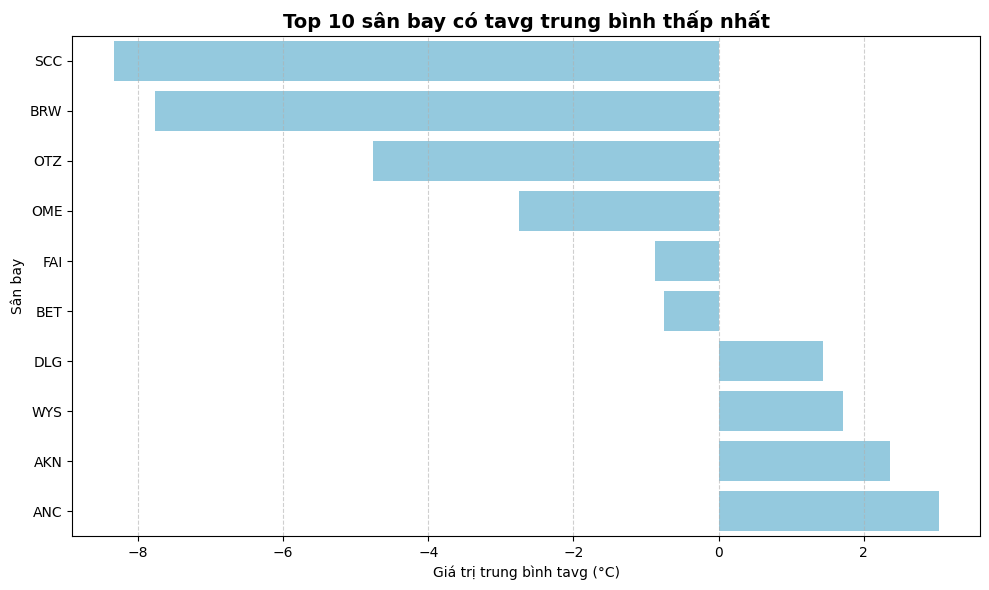

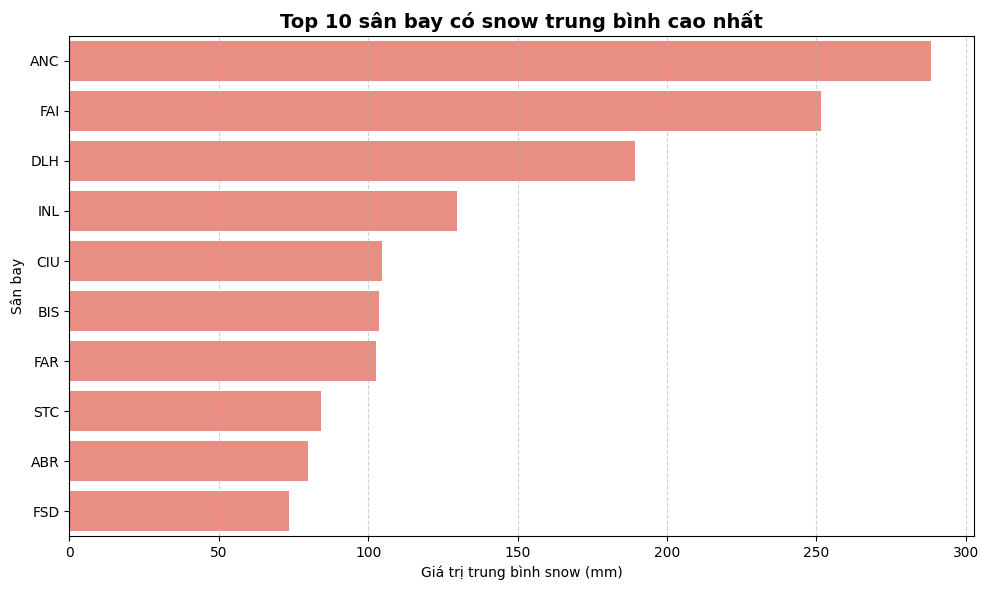

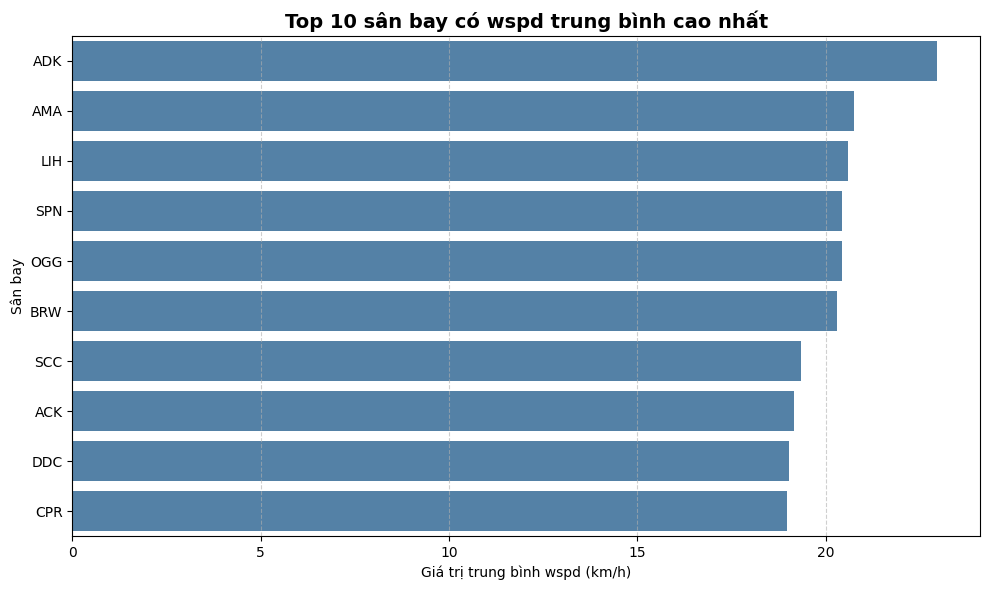

In [33]:
def plot_top10_airports_by_avg(
    df,
    value_col: str,
    airport_col: str = "airport_id",
    top: str = "high",
    unit: str = None,
    color: str = None,
    title: str = None
):
    """
    Vẽ biểu đồ Top 10 sân bay có giá trị trung bình cao nhất hoặc thấp nhất của một chỉ số.

    Tham số:
        df (pd.DataFrame): Dữ liệu chứa ít nhất [airport_col, value_col]
        value_col (str): Tên cột chỉ số cần tính trung bình (vd: 'tavg', 'snow', 'wspd')
        airport_col (str): Tên cột sân bay (vd: 'airport_id')
        top (str): 'high' để lấy 10 cao nhất, 'low' để lấy 10 thấp nhất
        unit (str): Đơn vị của chỉ số (vd: '°C', 'mm', 'km/h')
        color (str): Màu của cột (nếu không truyền sẽ tự chọn theo top)
        title (str): Tiêu đề (tự sinh nếu không có)
    """

    # Kiểm tra dữ liệu
    if value_col not in df.columns or airport_col not in df.columns:
        print(f"Thiếu cột '{value_col}' hoặc '{airport_col}' trong DataFrame!")
        return

    # Tính trung bình theo sân bay
    avg_df = df.groupby(airport_col)[value_col].mean().reset_index()

    # Lấy Top 10 cao hoặc thấp
    if top.lower() == "low":
        top_df = avg_df.nsmallest(10, value_col)
        top_label = "thấp nhất"
        color = color or "skyblue"
    else:
        top_df = avg_df.nlargest(10, value_col)
        top_label = "cao nhất"
        color = color or "salmon"

    # Tạo tiêu đề
    if not title:
        title = f"Top 10 sân bay có {value_col} trung bình {top_label}"

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_df,
        x=value_col,
        y=airport_col,
        palette=[color] * len(top_df)
    )

    plt.title(title, fontsize=14, fontweight="bold")
    xlabel = f"Giá trị trung bình {value_col}"
    if unit:
        xlabel += f" ({unit})"
    plt.xlabel(xlabel)
    plt.ylabel("Sân bay")
    plt.grid(axis="x", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
    
# Top 10 sân bay nóng nhất
plot_top10_airports_by_avg(df, value_col="tavg", top="low", unit="°C")

# Top 10 sân bay có lượng tuyết thấp nhất
plot_top10_airports_by_avg(df, value_col="snow", top="high", unit="mm")

# Top 10 sân bay gió mạnh nhất
plot_top10_airports_by_avg(df, value_col="wspd", top="high", unit="km/h", color="steelblue")


In [41]:
def plot_monthly_temp_and_precip(df, airport_id):
    """
    Vẽ lượng mưa (bar, y axis trái) và nhiệt độ (line, y axis phải) theo tháng
    bằng Plotly. Đảm bảo nhiệt độ nằm trên trục y thứ hai (bên phải).
    """
    # Lọc dữ liệu theo sân bay
    subset = df[df['airport_id'] == airport_id]
    if subset.empty:
        print(f"Không có dữ liệu cho airport_id: {airport_id}")
        return
    
    # Tính trung bình theo tháng (đảm bảo có các tháng 1..12)
    monthly_data = subset.groupby('month', as_index=False)[['tavg', 'prcp']].mean()
    monthly_data = monthly_data.sort_values('month')

    # Bar chart cho prcp bằng Plotly Express
    fig = px.bar(
        monthly_data,
        x='month',
        y='prcp',
        labels={'month': 'Tháng', 'prcp': 'Lượng mưa trung bình (mm)'},
        color_discrete_sequence=['skyblue'],
        title=f'Lượng mưa & Nhiệt độ trung bình theo tháng - Sân bay {airport_id}'
    )

    # Thêm trace line cho nhiệt độ, gán cho yaxis='y2'
    fig.add_trace(
        go.Scatter(
            x=monthly_data['month'],
            y=monthly_data['tavg'],
            mode='lines+markers',
            name='Nhiệt độ trung bình (°C)',
            line=dict(color='red', width=3),
            marker=dict(size=7),
            yaxis='y2'   # <-- quan trọng: gắn trace này lên y2
        )
    )

    # Cấu hình layout, khai báo yaxis2 (overlaying y, side right)
    fig.update_layout(
        xaxis=dict(dtick=1, title='Tháng'),
        yaxis=dict(title='Lượng mưa trung bình (mm)', showgrid=True),
        yaxis2=dict(
            title='Nhiệt độ trung bình (°C)',
            overlaying='y',
            side='right',
            showgrid=False
        ),
        legend=dict(title='', orientation='h', y=-0.18, x=0.25),
        template='plotly_white',
        width=900,
        height=520,
        margin=dict(t=80, b=80, l=80, r=80)
    )

    fig.show()
plot_monthly_temp_and_precip (df, "SPN")

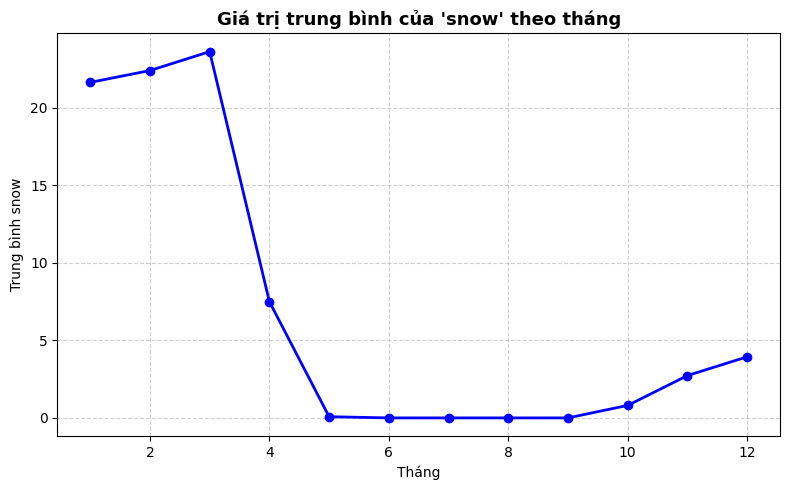

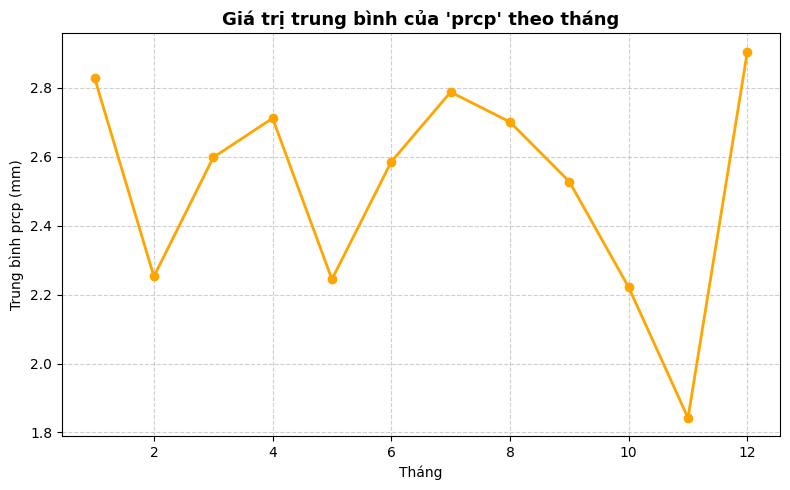

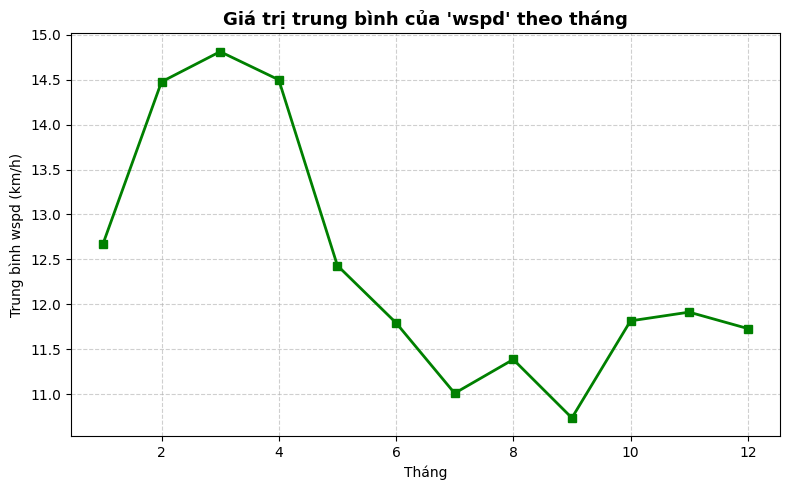

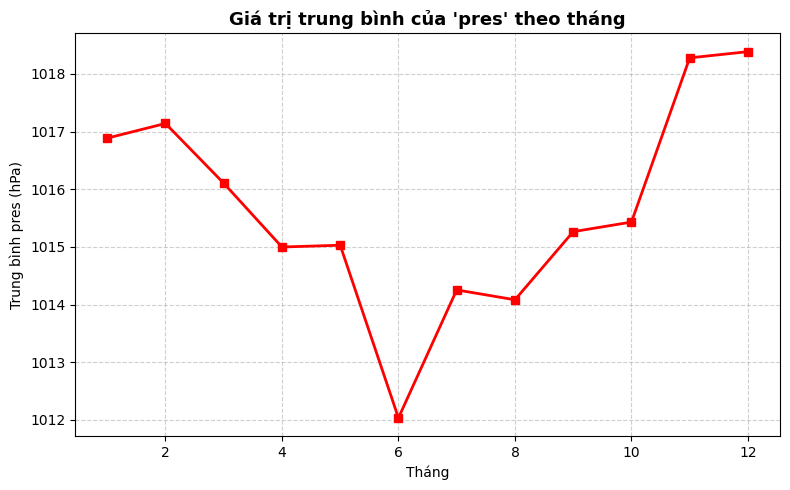

In [ ]:
def plot_monthly_average(df, month_col: str, value_col: str, 
                         color='blue', marker='o', title=None, unit=None):
    """
    Vẽ biểu đồ giá trị trung bình theo tháng cho một biến numerical.
    
    Parameters:
        df (pd.DataFrame): Dữ liệu
        month_col (str): Tên cột thể hiện tháng (1–12)
        value_col (str): Tên biến số cần tính trung bình (ví dụ: 'snow', 'temperature', 'rainfall')
        color (str): Màu của đường
        marker (str): Dấu marker cho điểm
        title (str): Tiêu đề biểu đồ (tự động nếu không truyền)
    """
    # Nhóm và tính trung bình
    monthly_avg = df.groupby(month_col)[value_col].mean()

    # Tạo biểu đồ
    plt.figure(figsize=(8, 5))
    plt.plot(monthly_avg.index, monthly_avg.values, 
             marker=marker, color=color, linewidth=2)
    
    if not title:
        title = f"Giá trị trung bình của '{value_col}' theo tháng"
    
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel("Tháng")
    ylabel = f"Trung bình {value_col}"
    if unit:
        ylabel += f" ({unit})"
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_monthly_average(df, month_col='month', value_col='snow', color='blue')
plot_monthly_average(df, month_col='month', value_col='prcp', color='orange', unit="mm")
plot_monthly_average(df, month_col='month', value_col='wspd', color='green', marker='s', unit="km/h")
plot_monthly_average(df, month_col='month', value_col='pres', color='red', marker='s', unit="hPa")

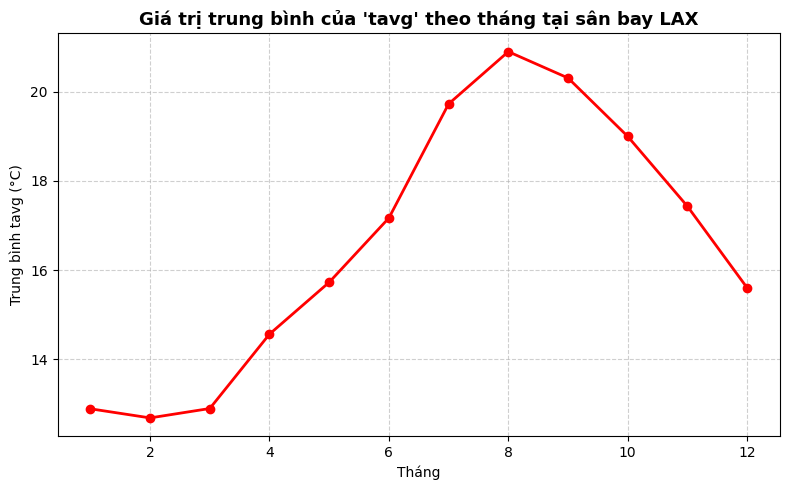

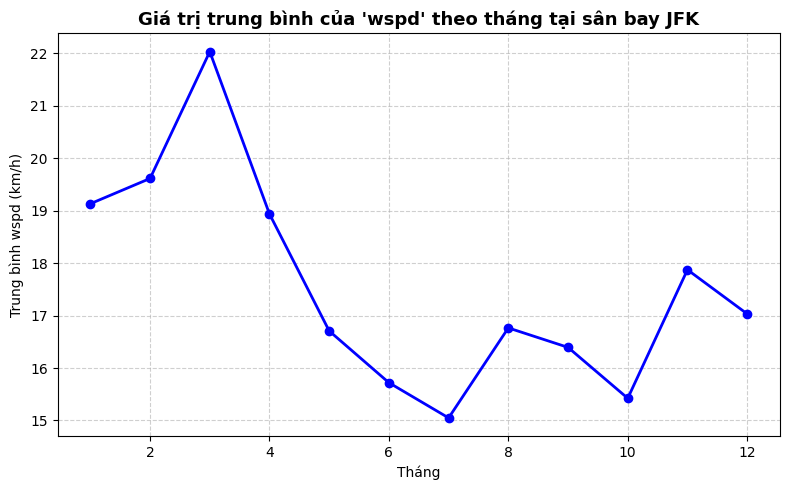

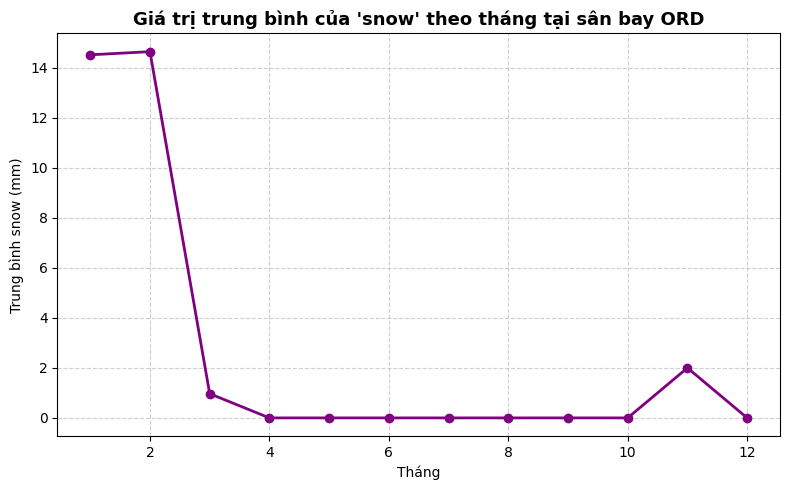

In [36]:
def plot_monthly_avg_by_airport(
    df, 
    airport_id, 
    value_col: str = "tavg", 
    month_col: str = "month", 
    color: str = "orange",
    marker: str = "o",
    unit: str = None,
    title: str = None
):
    """
    Vẽ biểu đồ giá trị trung bình theo tháng cho một sân bay cụ thể.

    Tham số:
        df (pd.DataFrame): Dữ liệu có ít nhất các cột [airport_id, month_col, value_col]
        airport_id (str | int): Mã sân bay cần vẽ
        value_col (str): Tên biến numerical cần vẽ (vd: 'tavg', 'snow', 'wspd')
        month_col (str): Tên cột thể hiện tháng (vd: 'month')
        color (str): Màu của đường vẽ
        marker (str): Ký hiệu điểm trên đường
        unit (str): Đơn vị hiển thị (vd: '°C', 'mm', 'km/h')
        title (str): Tiêu đề biểu đồ (nếu không có thì tự sinh)
    """
    # Lọc dữ liệu theo sân bay
    subset = df[df["airport_id"] == airport_id]
    if subset.empty:
        print(f"Không có dữ liệu cho airport_id: {airport_id}")
        return

    # Tính trung bình theo tháng
    monthly_avg = subset.groupby(month_col)[value_col].mean().sort_index()

    # Tạo biểu đồ
    plt.figure(figsize=(8, 5))
    plt.plot(
        monthly_avg.index, monthly_avg.values,
        marker=marker, color=color, linewidth=2
    )

    # Tạo tiêu đề
    if not title:
        title = f"Giá trị trung bình của '{value_col}' theo tháng tại sân bay {airport_id}"
    plt.title(title, fontsize=13, fontweight="bold")

    plt.xlabel("Tháng")
    ylabel = f"Trung bình {value_col}"
    if unit:
        ylabel += f" ({unit})"
    plt.ylabel(ylabel)

    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
    
# Nhiệt độ trung bình (°C)
plot_monthly_avg_by_airport(df, airport_id="LAX", value_col="tavg", unit="°C", color="red")

# Tốc độ gió trung bình (km/h)
plot_monthly_avg_by_airport(df, airport_id="JFK", value_col="wspd", unit="km/h", color="blue")

# Lượng tuyết trung bình (mm)
plot_monthly_avg_by_airport(df, airport_id="ORD", value_col="snow", unit="mm", color="purple")
